In [2]:
import os
import numpy as np
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [4]:
def build_model(hp):

    units1 = hp.Int('units1', 64, 160, step=16)
    units2 = hp.Int('units2', 32, 96, step=8)
    dropout = hp.Float('dropout', 0.25, 0.5, step=0.05)
    l2_reg = hp.Float('l2_reg', 1e-4, 5e-3, sampling='log')
    lr = hp.Float('lr', 3e-4, 1e-3, sampling='log')
    bidirectional = hp.Boolean('bidirectional')

    inputs = Input(shape=(x_train.shape[1], x_train.shape[2]))

    if bidirectional:
        x = Bidirectional(GRU(units1, return_sequences=True))(inputs)
    else:
        x = GRU(units1, return_sequences=True)(inputs)

    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    x = GRU(units2, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)

    attn = Attention()([x, x])

    x = GlobalAveragePooling1D()(attn)

    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    x = Dropout(dropout * 0.8)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss=SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

In [ ]:
data_path = "fliped augmenated data"

x = []
y = []

labels = sorted(os.listdir(data_path))

for label in labels:
    folder = os.path.join(data_path, label)
    if not os.path.isdir(folder):
      continue

    for file in os.listdir(folder):
        if file.endswith(".npy"):
            seq = np.load(os.path.join(folder, file))
            x.append(seq)
            y.append(label)

x = np.array(x)
y = np.array(y)

print("x shape:", x.shape)
print("y shape:", y.shape)

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

In [43]:
samples, timesteps, features = x.shape

scaler = StandardScaler()
x_reshaped = x.reshape(-1, features)
x_scaled = scaler.fit_transform(x_reshaped)
x = x_scaled.reshape(samples, timesteps, features)

x = x_scaled.reshape(samples, timesteps, features)
print("sclaed x shape:", x.shape)

sclaed x shape: (7008, 20, 174)


In [44]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y_encoded, test_size=0.2, random_state=42
)
print(f"x train shape: {x_train.shape}")
print(f"y train shape: {y_train.shape}")

x train shape: (5606, 20, 174)
y train shape: (5606,)


In [45]:
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train),
y=y_train)

class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:")

for idx, weight in class_weight_dict.items():
    label_name = encoder.inverse_transform([idx])[0]
    print(f"  {label_name}: {weight:.3f}")

Class weights:
  angry: 1.116
  bad: 0.968
  bathroom: 1.153
  clothes: 1.068
  come: 1.013
  drink: 0.984
  eat: 1.153
  father: 1.153
  go: 1.095
  good: 1.049
  happy: 0.819
  hello: 0.917
  help: 1.102
  home: 0.850
  how: 1.075
  hungry: 1.013
  money: 1.138
  mother: 1.024
  need: 1.123
  no: 0.922
  please: 0.768
  sad: 0.922
  sorry: 1.116
  thank you: 0.937
  tired: 1.068
  want: 1.049
  what: 1.109
  when: 1.184
  where: 0.894
  who: 0.793
  why: 1.049
  yes: 0.834


In [46]:
input_shape = (x.shape[1],x.shape[2])
num_classes = len(np.unique(y))

In [47]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=10, executions_per_trial=1, directory='tuner_results', project_name='gru_tuning',overwrite=True)
tuner.search(x_train, y_train, epochs=50, validation_data=(x_test, y_test),  class_weight=class_weight_dict, callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

Trial 10 Complete [00h 02m 08s]
val_accuracy: 0.8894436359405518

Best val_accuracy So Far: 0.9229671955108643
Total elapsed time: 00h 20m 51s


In [48]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)

{'units1': 144, 'units2': 80, 'dropout': 0.4, 'l2_reg': 0.0016214429293590431, 'lr': 0.00033495676142302844, 'bidirectional': True}


In [49]:
history = best_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), class_weight=class_weight_dict, callbacks = [tf.keras.callbacks.EarlyStopping( monitor='val_loss', patience=7, restore_best_weights=True), tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6,verbose=1)],verbose=1)

Epoch 1/50
176/176 [==============================] - 7s 24ms/step - loss: 0.1182 - accuracy: 0.9809 - val_loss: 0.3887 - val_accuracy: 0.9187 - lr: 3.3496e-04
Epoch 2/50
176/176 [==============================] - 4s 21ms/step - loss: 0.1125 - accuracy: 0.9829 - val_loss: 0.3993 - val_accuracy: 0.9223 - lr: 3.3496e-04
Epoch 3/50
176/176 [==============================] - 4s 22ms/step - loss: 0.1088 - accuracy: 0.9839 - val_loss: 0.4289 - val_accuracy: 0.9101 - lr: 3.3496e-04
Epoch 4/50
176/176 [==============================] - 3s 18ms/step - loss: 0.1115 - accuracy: 0.9827 - val_loss: 0.3951 - val_accuracy: 0.9244 - lr: 3.3496e-04
Epoch 5/50
176/176 [==============================] - 3s 18ms/step - loss: 0.1020 - accuracy: 0.9864 - val_loss: 0.5234 - val_accuracy: 0.8973 - lr: 3.3496e-04
Epoch 6/50
176/176 [==============================] - ETA: 0s - loss: 0.1030 - accuracy: 0.9843
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00016747838526498526.
176/176 [==================

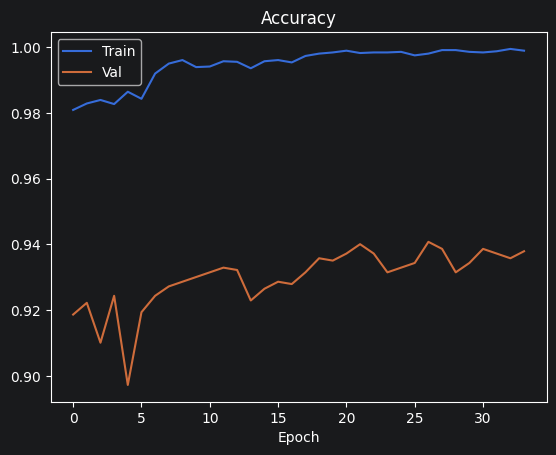

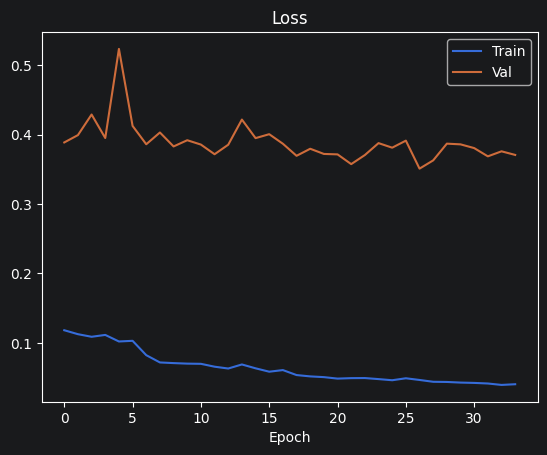

In [50]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import joblib
best_model.save("final tuned gru model.h5")
joblib.dump(scaler, "final tuned scaler.pkl")
joblib.dump(encoder, "final tuned encoder.pkl")